# Reproducing baseline Tg prediction
Here we replicate the prediction results from Rasulev 2024 Nature paper.

Using training and test data w/ target variable: log(Tg) and features: 15 descriptors.

Source: https://github.com/bakhras/ml_Tg_predictor

In [1]:
# import libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, root_mean_squared_error

In [2]:
pd.set_option('display.max_colwidth', 100)  # Limit to 100 characters

Setting up local imports of custom python functions

In [3]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor


In [4]:
figs_dir = PROJECT_ROOT / "figs" 

In [5]:
def get_performance_metrics(y_true, y_pred):
    """
    Calculate and display model prediction performance metrics: R2-score and RMSE
    Parameters:
        y_true (numpy.ndarray): 1D-array with true value of the target variable
        y_pred (numpy.ndarray): 1D-array with predicted value of the target variable
    Returns:
        dict: Dictionary containing R2-score and RMSE
    """
    print(f"R2-score:: {r2_score(y_true, y_pred):.3f}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_true, y_pred):.4f}")
    
    return {
        'r2_score': r2_score(y_true, y_pred),
        'rmse': root_mean_squared_error(y_true, y_pred)
    }

# Load data
Read CSV files saved locally from URL.

Training data

In [6]:
train_data_path = PROJECT_ROOT / 'data' / 'raw' / "data_902_original_15desc_logTg_train.csv"
train_df = pd.read_csv(train_data_path)  # Local file path
print(f"Training data shape: {train_df.shape}")
train_df.head()

Training data shape: (683, 19)


,No,Index,nCsp2,SpMax_EA(ri),SpMax_AEA(dm),SM11_EA,Eig03_EA,B03[C-N],S1K,piPC05,piPC07,AAC,SIC4,SpDiam_B(e),SpMax1_Bh(i),Mor31v,TE1,logTg,Series
0,1,PPD_007,1,1.568,3.150,8.507,-1.000,0,4.494,0.000,0.000,0.722,0.000,4.599,3.374,0.079,1.028,2.7077,T
1,2,PPD_008,1,2.352,3.621,8.507,-1.000,1,3.948,0.000,0.000,1.371,0.000,4.608,3.425,0.023,2.840,2.8520,T
2,3,PPD_010,2,2.446,4.150,10.289,0.821,1,8.896,2.565,2.197,1.096,1.000,4.766,3.443,0.161,5.075,2.8177,T
3,5,PPD_019,1,2.378,3.898,9.304,0.471,0,6.468,2.485,0.000,1.299,0.875,4.717,3.427,0.031,3.641,2.7552,T
4,6,PPD_029,1,2.379,3.779,9.306,1.887,0,18.221,3.045,2.944,0.426,0.726,4.656,3.383,1.177,10.695,2.7687,T


Testing data

In [7]:
test_data_path = PROJECT_ROOT / 'data' / 'raw' / "data_c219_Tg_test.csv"
test_df = pd.read_csv(test_data_path)
print(f"Test data shape: {test_df.shape}")
test_df.head()


Test data shape: (219, 17)


,No,logTg,nCsp2,SpMax_EA(ri),SpMax_AEA(dm),SM11_EA,Eig03_EA,B03[C-N],S1K,piPC05,piPC07,AAC,SIC4,SpDiam_B(e),SpMax1_Bh(i),Mor31v,TE1
0,1,2.7178,0.074074,0.797028,0.808405,0.811272,0.585265,0,0.178967,0.351211,0.187420,0.832288,0.907,0.667689,0.636364,0.526942,0.949016
1,2,2.7854,0.000000,0.777134,0.593750,0.758583,0.085679,0,0.069872,0.000000,0.000000,0.000000,0.000,0.617076,0.528796,0.558900,0.944596
2,3,2.7317,0.000000,0.285319,0.717457,0.000000,0.164735,0,0.061663,0.000000,0.000000,0.411865,0.400,0.440184,0.354593,0.515793,0.943993
3,4,2.5577,0.148148,0.883908,0.705172,0.867878,0.807740,0,0.296866,0.738488,0.683285,0.424415,0.984,0.839213,0.827225,0.473430,0.952442
4,5,2.4364,0.074074,0.642156,0.599353,0.661710,0.578228,0,0.151329,0.292388,0.226674,0.625214,0.947,0.687628,0.665873,0.580453,0.949632


The target variable to predict is **log(Tg)**

In [8]:
target_col = "logTg"

## Fig 1.a) Distribution of target variable: logTg

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


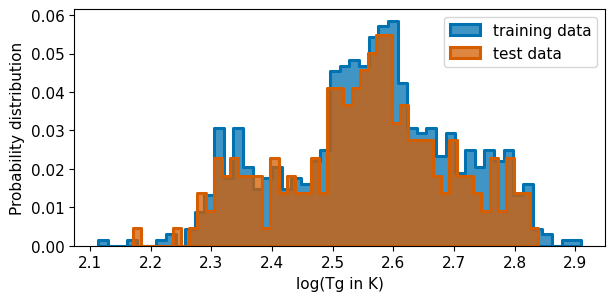

In [9]:
# Set figure size in inches (width, height)
fig, ax = plt.subplots(figsize=(6.85, 3.07))  # 174mm x 78mm
# Plot training data distribution
sns.histplot(
    train_df[target_col],
    bins=50,
    label='training data',
    stat='probability',  # Normalize to show probability density
    element="step",
    linewidth=2.2,
    ax=ax,
    color="#0072B2", # blue
)
sns.histplot(
        test_df[target_col],
        bins=50,
        label='test data',
        stat='probability',  # Normalize to show probability density
        element="step",
        linewidth=2.2,
        ax=ax,
        color="#D55E00", # vermillion
    )
# Set axis label and tick font sizes to 11 points
ax.tick_params(axis='both', which='major', labelsize=11)
ax.set_xlabel('log(Tg in K)', fontsize=11)
ax.set_ylabel('Probability distribution', fontsize=11)
# Optionally set title font size
#ax.set_title('Distribution of log(Tg in K) in Training vs Test Sets', fontsize=11)
plt.legend(fontsize=11)
#plt.grid(True, linestyle='--', color='gray', alpha=0.01)
# Save as EPS
plt.savefig(
    figs_dir / 'distribution_log_Tg_revised.eps',
    format='eps',
    bbox_inches='tight',
    dpi=400
)
plt.show()
plt.close()

Input feature columns used for model training

In [10]:
feat_cols = [
    col_ for col_ in train_df.columns if col_ not in ['No','Index','logTg','Series']
]
print("Number of features:", len(feat_cols))
feat_cols

Number of features: 15


['nCsp2',
 'SpMax_EA(ri)',
 'SpMax_AEA(dm)',
 'SM11_EA',
 'Eig03_EA',
 'B03[C-N]',
 'S1K',
 'piPC05',
 'piPC07',
 'AAC',
 'SIC4',
 'SpDiam_B(e)',
 'SpMax1_Bh(i)',
 'Mor31v',
 'TE1']

**Supplementary Fig 1. Features descriptors in relation to the target variable**

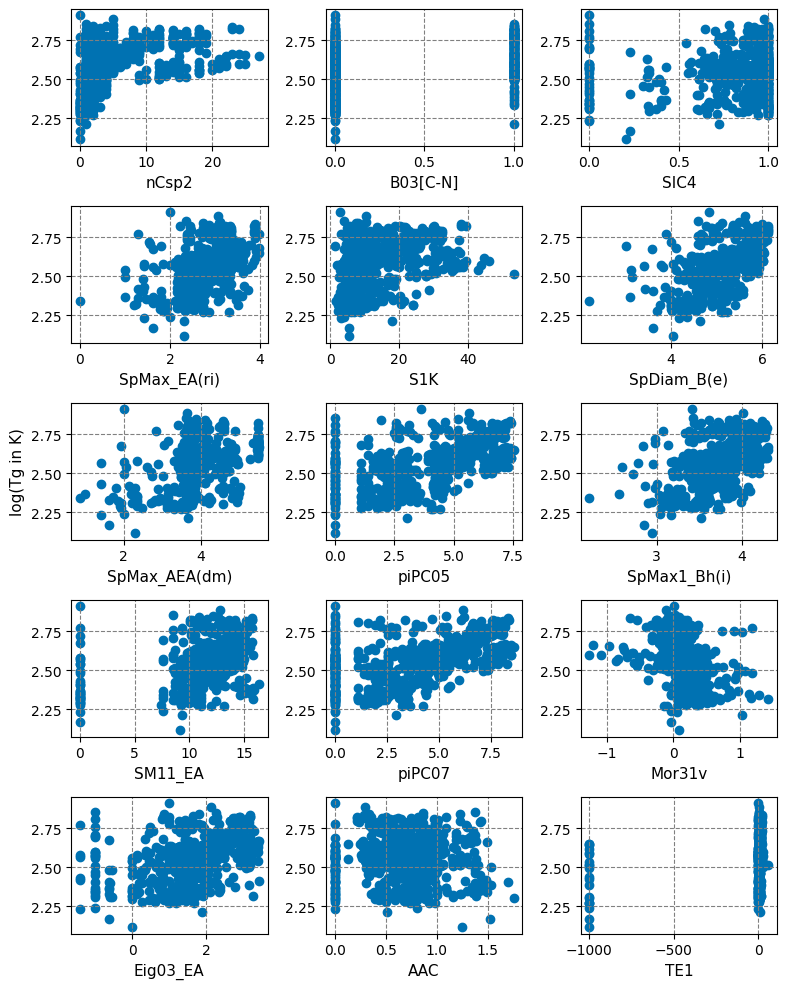

In [11]:
# Plot correlation between each feature and target variable
# Set figure size in inches (width, height)
fig, ax = plt.subplots(5, 3, figsize=(8, 10))  # 348mm x 234mm
plt_n_ = 5
for i, feat_ in enumerate(feat_cols):
    ax[i%plt_n_][int(i/plt_n_)].scatter(
        train_df[feat_],
        train_df[target_col],
        color='#0072B2'
    )
    ax[i%plt_n_][int(i/plt_n_)].tick_params(axis='both', which='major', labelsize=10)
    if (i % plt_n_ == 2) & (int(i/plt_n_) == 0):
        ax[i%plt_n_][int(i/plt_n_)].set_ylabel("log(Tg in K)", fontsize=11)
    ax[i%plt_n_][int(i/plt_n_)].set_xlabel(feat_, fontsize=11)
    ax[i%plt_n_][int(i/plt_n_)].grid(True, linestyle='--', color='gray')
#plt.suptitle(f"Correlation between feature descriptors and log(Tg) values")
plt.tight_layout()
# Save as EPS
plt.savefig(
    figs_dir / 'correlation_log_Tg_SVM_descriptor_features_revised.eps',
    format='eps',
    bbox_inches='tight',
    dpi=400
)
plt.show()
plt.close()

# Data processing

In [12]:
# converting features data to a numpy array (n, m) given n samples and m features
## training data
X_train = train_df[feat_cols].values
print("Training features array shape: ", X_train.shape)

## test data
X_test = test_df[feat_cols].values
print("Test features array shape: ", X_test.shape)

Training features array shape:  (683, 15)
Test features array shape:  (219, 15)


In [13]:
# converting target values to a numpy array (n, 1)
## training data
y_train = train_df[target_col].values.reshape(-1, 1)
print("Training target array shape: ", y_train.shape)

## test data
y_test = test_df[target_col].values.reshape(-1, 1)
print("Test target array shape: ", y_test.shape)

Training target array shape:  (683, 1)
Test target array shape:  (219, 1)


## Scaling data for better prediction

Scaling features and target variable to better fit SVR model

**Max-Min scaler**: This scales the data within the range [0, 1]

In [14]:
# --- MinMaxScaler ---
X_train_minmax_scaler = MinMaxScaler().fit(X_train)
X_train_minmax = X_train_minmax_scaler.transform(X_train)

X_test_minmax_scaler = MinMaxScaler().fit(X_test)
X_test_minmax = X_test_minmax_scaler.transform(X_test)

y_train_minmax_scaler = MinMaxScaler().fit(y_train)
y_train_minmax = y_train_minmax_scaler.transform(y_train)
y_test_minmax_scaler = MinMaxScaler().fit(y_test)
y_test_minmax = y_test_minmax_scaler.transform(y_test)

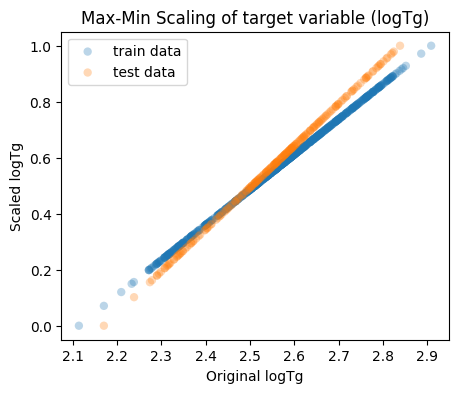

In [15]:
plt.figure(figsize=(5, 4))
plt.scatter(
    y_train,
    y_train_minmax,
    label='train data',
    alpha=0.3,
    edgecolor='none'
)
plt.scatter(
    y_test,
    y_test_minmax,
    label='test data',
    alpha=0.3,
    edgecolor='none'
)
plt.title('Max-Min Scaling of target variable (logTg)')
plt.xlabel('Original logTg')
plt.ylabel('Scaled logTg')
plt.legend()
plt.show()

**Standard Scaler**: This scales data to a standard normal distribution 

In [16]:
X_train_std_scaler = StandardScaler().fit(X_train)
X_train_std = X_train_std_scaler.transform(X_train)
X_test_std_scaler = StandardScaler().fit(X_test)
X_test_std = X_test_std_scaler.transform(X_test)

y_train_std_scaler = StandardScaler().fit(y_train)
y_train_std = y_train_std_scaler.transform(y_train)
y_test_std_scaler = StandardScaler().fit(y_test)
y_test_std = y_test_std_scaler.transform(y_test)

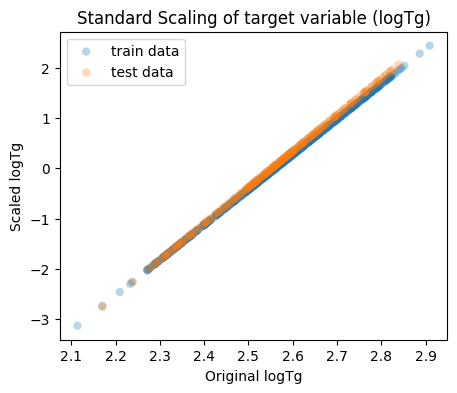

In [17]:
plt.figure(figsize=(5, 4))
plt.scatter(
    y_train,
    y_train_std,
    label='train data',
    alpha=0.3,
    edgecolor='none'
)
plt.scatter(
    y_test,
    y_test_std,
    label='test data',
    alpha=0.3,
    edgecolor='none'
)
plt.title('Standard Scaling of target variable (logTg)')
plt.xlabel('Original logTg')
plt.ylabel('Scaled logTg')
plt.legend()
plt.show()

# Support Vector Regressor
It is a strong regression technique to fit a model of continuous variable based on set of features. It involves a kernel function meaning what kind of relationship nearby data-points have like linear or non-linear. 
* Then it has a epsilon parameter which defines a tube around the model function where no penalty is applied meaning if the model prediction value and real value are epsilon apart then it's fine.
* Then beyond the epsilon tube we have the outliers and **support vectors** drawn from the epsilon tube edge to the outlier data-point.
* The goal is to minimize the support vectors but also to keep model function as simple as possible (trivial case: y=b)

For the current case, we don't know whether the descriptors impact the target variable linearly or non-linearly. But the target variable is normally distributed. Using a **radial basis function** as a kernel would fit a model where features that are radially close to each other will yeild a similar target variable. Hence, we define the 3 key model parameters,
* **epsilon**: no penalty is associated in the training loss function with points predicted within a distance epsilon from the actual value. Ideally small but relax it if training fit performance is bad.
* **C**: capacity constant used for regularization. Increasing this makes the contribution of outliers stronger in optimization. Increasing will improve training model fit but lead to overfitting. Reduce C for regularization.
* **gamma**: The radial basis function is defined as exp(-gamma* (x_i - x_j)^2) where x_i and x_j are input features. Gamma is 1/variance thus defining the spread of the radial function. At Large Gamma even nearby features would yield different results. Smaller gamma means more generalized radial distribution with respect to input features. Reduce gamma for regularization.

## Loading the SVM model within supplementary data
We will look into the paramters used for regression modelling

In [18]:
with open(PROJECT_ROOT / 'data' / 'raw' / 'svr_model.pickle', 'rb') as file:
    # Load the SVR model from the file
    loaded_svr_model = pickle.load(file)

/home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVR from version 1.3.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [19]:
loaded_svr_model

,kernel,'rbf'
,degree,3
,gamma,1.1
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.031
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## SVM regressor
* Within supplementary text the  kernel mentioned is 'rbf' and C = 1, gamma = 5, but within model pickle file: C = 10, gamma = 1.1. So we check both set of values.
* Additionally the text didn't mention an epsilon value but the model has 0.031. The default value in scikit learn is 0.1 which is much relaxed.
* review R2 score for each case.

In [20]:
def test_model_fit(
        X_scaled,
        y_scaled,
        C_,
        gamma_,
        epsilon
    ):
    """
    Train a Support Vector Regression (SVR) model with the given hyperparameters.
    Parameters:
        X_scaled (np.ndarray): Scaled input features.
        y_scaled (np.ndarray): Scaled target values.
        C_ (float): Regularization parameter.
        gamma_ (float): Kernel coefficient.
        epsilon (float): Epsilon in the epsilon-SVR model.
    Returns:
        SVR: Trained SVR model.
        np.ndarray: Predicted values on the training set.
    """
    print(f"C: {C_}; gamma: {gamma_:.2f}; epsilon: {epsilon}")
    # Initialize the SVR model with the given hyperparameters
    regr = SVR(
        kernel='rbf', C=C_, gamma=gamma_, epsilon=epsilon
    )
    # Fit the SVR model to the scaled data
    SVM_fit_model = regr.fit(X_scaled, y_scaled)
    # Predict on the training data
    y_pred = SVM_fit_model.predict(X_scaled)
    # Calculate and print the R2 score on the training data
    print(f'Training fit R2-score: {r2_score(y_scaled, y_pred):.3f}')
    
    return SVM_fit_model, y_pred

In [21]:
hyperparams = {
    "Option1": {"C": 1, "gamma": 5, "epsilon": 0.1},
    "Option2": {"C": 1, "gamma": 5, "epsilon": 0.031},
    "Option3": {"C": 1, "gamma": 10, "epsilon": 0.031},
    "Option4": {"C": 10, "gamma": 1.1, "epsilon": 0.031},
    "Option5": {"C": 10, "gamma": 10, "epsilon": 0.031},
    "Option6": {"C": 10, "gamma": 1.1, "epsilon": 0.1}
}

1. Max-Min Scaling of features and target variable

In [22]:
for params_ in hyperparams:
    _ = test_model_fit(
        X_scaled=X_train_minmax,
        y_scaled=y_train_minmax.ravel(),
        C_=hyperparams[params_]['C'],
        gamma_=hyperparams[params_]['gamma'],
        epsilon=hyperparams[params_]['epsilon']
    )

C: 1; gamma: 5.00; epsilon: 0.1
Training fit R2-score: 0.787
C: 1; gamma: 5.00; epsilon: 0.031
Training fit R2-score: 0.856
C: 1; gamma: 10.00; epsilon: 0.031
Training fit R2-score: 0.905
C: 10; gamma: 1.10; epsilon: 0.031
Training fit R2-score: 0.817
C: 10; gamma: 10.00; epsilon: 0.031
Training fit R2-score: 0.965
C: 10; gamma: 1.10; epsilon: 0.1
Training fit R2-score: 0.776


2. Standard Scaling of the features and target variable

In [23]:
for params_ in hyperparams:
    _ = test_model_fit(
        X_scaled=X_train_std,
        y_scaled=y_train_std.ravel(),
        C_=hyperparams[params_]['C'],
        gamma_=hyperparams[params_]['gamma'],
        epsilon=hyperparams[params_]['epsilon']
    )

C: 1; gamma: 5.00; epsilon: 0.1
Training fit R2-score: 0.894
C: 1; gamma: 5.00; epsilon: 0.031
Training fit R2-score: 0.899
C: 1; gamma: 10.00; epsilon: 0.031
Training fit R2-score: 0.890
C: 10; gamma: 1.10; epsilon: 0.031
Training fit R2-score: 0.990
C: 10; gamma: 10.00; epsilon: 0.031
Training fit R2-score: 0.999
C: 10; gamma: 1.10; epsilon: 0.1
Training fit R2-score: 0.984


### Best model
Using C = 10; gamma = 1.1 and epsilon = 0.031 as per the pickle file in github repo.

In [24]:
model_results_dict = {}

**Standard scaling**

In [25]:
SVM_best_fit_std, y_train_std_pred = test_model_fit(
    X_scaled=X_train_std,
    y_scaled=y_train_std.ravel(),
    C_=10,
    gamma_=1.1,
    epsilon=0.031
)

y_train_pred_unscaled_std = y_train_std_scaler.inverse_transform(y_train_std_pred.reshape((-1, 1)))

model_results_dict['Training_StandardScaling'] = get_performance_metrics(
    y_true=y_train,
    y_pred=y_train_pred_unscaled_std
)

C: 10; gamma: 1.10; epsilon: 0.031
Training fit R2-score: 0.990
R2-score:: 0.990
Root Mean Squared Error: 0.0144


**Max-Min Scaling**

In [26]:
SVM_best_fit_minmax, y_train_minmax_pred = test_model_fit(
    X_scaled=X_train_minmax,
    y_scaled=y_train_minmax.ravel(),
    C_=10,
    gamma_=1.1,
    epsilon=0.031
)

y_train_pred_unscaled_minmax = y_train_minmax_scaler.inverse_transform(y_train_minmax_pred.reshape((-1, 1)))

model_results_dict['Training_MinMaxScaling'] = get_performance_metrics(
    y_true=y_train,
    y_pred=y_train_pred_unscaled_minmax
)

C: 10; gamma: 1.10; epsilon: 0.031
Training fit R2-score: 0.817
R2-score:: 0.817
Root Mean Squared Error: 0.0611


**Supplementary figure: True vs. Predicted target values - Training data**

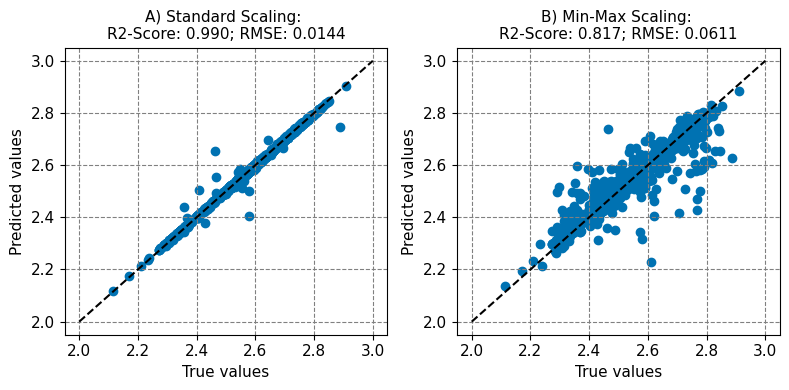

In [43]:
# Set figure size in inches (width, height)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))  # 174mm x 78mm
ax[0].scatter(
    y_train,
    y_train_pred_unscaled_std,
    color='#0072B2' # strong blue
)
ax[0].plot(
    [2, 3], [2, 3], color='black', linestyle='--'
)
# Set axis label and tick font sizes to 11 points
ax[0].tick_params(axis='both', which='major', labelsize=11)
ax[0].set_xlabel('True values', fontsize=11)
ax[0].set_ylabel('Predicted values', fontsize=11)
ax[0].grid(True, linestyle='--', color='gray')
ax[0].set_title(
    "A) Standard Scaling: \nR2-Score: {0:.3f}; RMSE: {1:.4f}".format(
        model_results_dict['Training_StandardScaling']['r2_score'],
        model_results_dict['Training_StandardScaling']['rmse']
    ),
    fontsize=11
)
ax[1].scatter(
    y_train,
    y_train_pred_unscaled_minmax,
    color='#0072B2' # strong blue
)
ax[1].plot(
    [2, 3], [2, 3], color='black', linestyle='--'
)
# Set axis label and tick font sizes to 11 points
ax[1].tick_params(axis='both', which='major', labelsize=11)
ax[1].set_xlabel('True values', fontsize=11)
ax[1].set_ylabel('Predicted values', fontsize=11)
ax[1].grid(True, linestyle='--', color='gray')
ax[1].set_title(
    "B) Min-Max Scaling: \nR2-Score: {0:.3f}; RMSE: {1:.4f}".format(
        model_results_dict['Training_MinMaxScaling']['r2_score'],
        model_results_dict['Training_MinMaxScaling']['rmse']
    ),
    fontsize=11
)
# labels = ['A)', 'B)']
# for idx, ax_ in enumerate(ax.flat):
#     ax_.text(
#         0, 1.06, labels[idx], 
#         transform=ax_.transAxes, 
#         fontsize=11, va='top', ha='left'
#     )
#plt.suptitle("True vs Predicted Values for training dataset", fontsize=12)
# Save as EPS
plt.tight_layout()
plt.savefig(
    figs_dir / 'SVM_true_vs_predicted_training_revised.eps',
    format='eps',
    bbox_inches='tight',
    dpi=400
)
plt.show()
plt.close()

## Validating model on independent test dataset

In [44]:
y_test_minmax_pred = SVM_best_fit_minmax.predict(X_test_minmax)

y_test_pred_unscaled_minmax = y_test_minmax_scaler.inverse_transform(y_test_minmax_pred.reshape((-1, 1)))
y_test_pred_unscaled_minmax.shape

model_results_dict['Testing_MinMaxScaling'] = get_performance_metrics(
    y_true=y_test,
    y_pred=y_test_pred_unscaled_minmax
)

R2-score:: 0.659
Root Mean Squared Error: 0.0811


In [45]:
y_test_std_pred = SVM_best_fit_std.predict(X_test_std)

y_test_pred_unscaled_std = y_test_std_scaler.inverse_transform(y_test_std_pred.reshape((-1, 1)))
y_test_pred_unscaled_std.shape

model_results_dict['Testing_StandardScaling'] = get_performance_metrics(
    y_true=y_test,
    y_pred=y_test_pred_unscaled_std
)

R2-score:: 0.732
Root Mean Squared Error: 0.0719


**Supplementary Figure: True vs Predicted values - testing data**

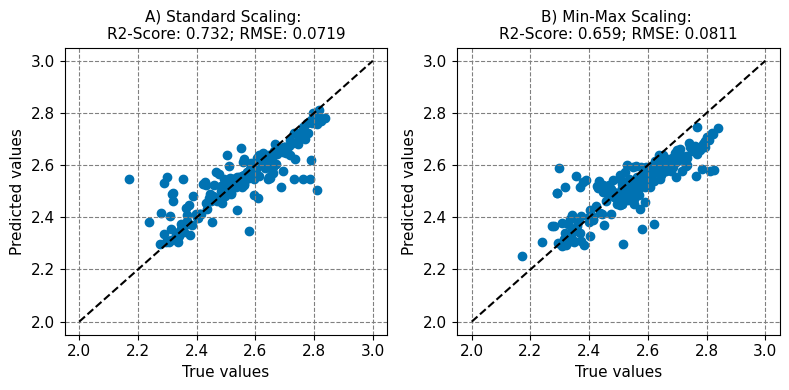

In [47]:
# Set figure size in inches (width, height)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))  # 174mm x 78mm
ax[0].scatter(
    y_test,
    y_test_pred_unscaled_std,
    color='#0072B2' # strong blue
)
ax[0].plot(
    [2, 3], [2, 3], color='black', linestyle='--'
)
# Set axis label and tick font sizes to 11 points
ax[0].tick_params(axis='both', which='major', labelsize=11)
ax[0].set_xlabel('True values', fontsize=11)
ax[0].set_ylabel('Predicted values', fontsize=11)
ax[0].grid(True, linestyle='--', color='gray')
ax[0].set_title(
    "A) Standard Scaling: \nR2-Score: {0:.3f}; RMSE: {1:.4f}".format(
        model_results_dict['Testing_StandardScaling']['r2_score'],
        model_results_dict['Testing_StandardScaling']['rmse']
    ),
    fontsize=11
)
ax[1].scatter(
    y_test,
    y_test_pred_unscaled_minmax,
    color='#0072B2' # strong blue
)
ax[1].plot(
    [2, 3], [2, 3], color='black', linestyle='--'
)
# Set axis label and tick font sizes to 11 points
ax[1].tick_params(axis='both', which='major', labelsize=11)
ax[1].set_xlabel('True values', fontsize=11)
ax[1].set_ylabel('Predicted values', fontsize=11)
ax[1].grid(True, linestyle='--', color='gray')
ax[1].set_title(
    "B) Min-Max Scaling: \nR2-Score: {0:.3f}; RMSE: {1:.4f}".format(
        model_results_dict['Testing_MinMaxScaling']['r2_score'],
        model_results_dict['Testing_MinMaxScaling']['rmse']
    ),
    fontsize=11
)
# labels = ['A)', 'B)']
# for idx, ax_ in enumerate(ax.flat):
#     ax_.text(
#         0, 1.06, labels[idx], 
#         transform=ax_.transAxes, 
#         fontsize=12, va='top', ha='left'
#     )
#plt.suptitle("True vs Predicted Values for testing dataset", fontsize=12)
# Save as EPS
plt.tight_layout()
plt.savefig(
    figs_dir / 'SVM_true_vs_predicted_testing_revised.eps',
    format='eps',
    bbox_inches='tight',
    dpi=400
)
plt.show()
plt.close()
# Save model and results
# Save best fit SVM models


# Save model and results

In [ ]:
# Save best fit SVM models

## Max-Min Scaling
with open(PROJECT_ROOT / 'data' / 'processed' / 'svm_models' / 'svm_best_fit_minmax.pkl', 'wb') as f:
    pickle.dump(SVM_best_fit_minmax, f)

## Standard Scaling
with open(PROJECT_ROOT / 'data' / 'processed' / 'svm_models' / 'svm_best_fit_std.pkl', 'wb') as f:
    pickle.dump(SVM_best_fit_std, f)

In [ ]:
# Save model results dictionary to HJSON file
import hjson

# Save as HJSON
with open(PROJECT_ROOT / 'data' / 'processed' / 'svm_models' / 'svm_model_results.hjson', 'w') as f:
    hjson.dump(model_results_dict, f)

## Visualizing ALE plots
Accumulated Local Effects (ALE) for SVM regressor visualizes the marginal effect of a feature on the predicted outcome, while accounting for correlations with other features.

Calculate the difference in the prediction when the feature value is replaced with the upper and lower limit of the interval. 

In [ ]:
feat_cols

['nCsp2',
 'SpMax_EA(ri)',
 'SpMax_AEA(dm)',
 'SM11_EA',
 'Eig03_EA',
 'B03[C-N]',
 'S1K',
 'piPC05',
 'piPC07',
 'AAC',
 'SIC4',
 'SpDiam_B(e)',
 'SpMax1_Bh(i)',
 'Mor31v',
 'TE1']

In [ ]:
SVM_best_fit_std

,kernel,'rbf'
,degree,3
,gamma,1.1
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.031
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [ ]:
X_train_std.shape

(683, 15)

**Supplementary Figure: ALE plots**

In [ ]:
def get_ALE(X, model_fit, feat_index=0, num_intervals = 10):
    """
    """
    # initialize array to save ALE values
    ale_values = np.zeros(num_intervals)
    # feature vector
    X_feat = X[:,feat_index]
    # Create intervals for the chosen feature
    interval_edges = np.linspace(
        X_feat.min(), X_feat.max(), num_intervals + 1
    )
    # loop over the range of feature values defined via intervals 
    for i in range(num_intervals):
        # Find data points within the current interval
        mask = (X_feat >= interval_edges[i]) & (X_feat < interval_edges[i+1])
    
        if np.any(mask):
            X_interval_lower = X[mask,:].copy()
            X_interval_lower[:,feat_index] = X[mask,feat_index].min()
            predictions_lower = model_fit.predict(X_interval_lower)
            
            X_interval_upper = X[mask,:].copy()
            X_interval_upper[:,feat_index] = X[mask,feat_index].max()
            predictions_upper = model_fit.predict(X_interval_upper)
            
            # Average local effect for the interval
            ale_values[i] = np.mean(predictions_upper - predictions_lower)
    
    plt.figure(figsize=(4, 3))
    plt.plot(
        interval_edges[:-1],
        ale_values
    )
    plt.xlabel('Input feature value')
    plt.ylabel('ALE (accumulated local effect)')
    plt.show()

nCsp2


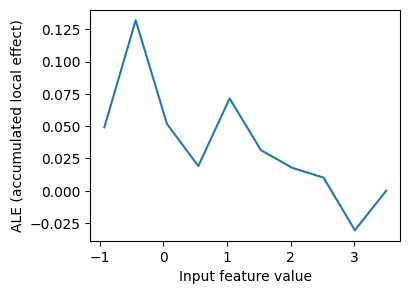

SpMax_EA(ri)


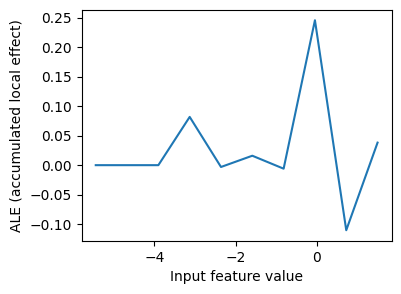

SpMax_AEA(dm)


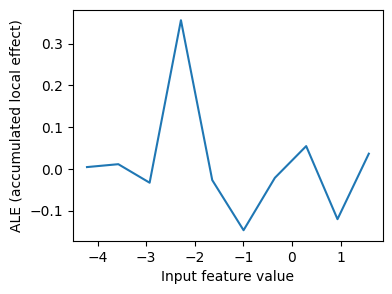

SM11_EA


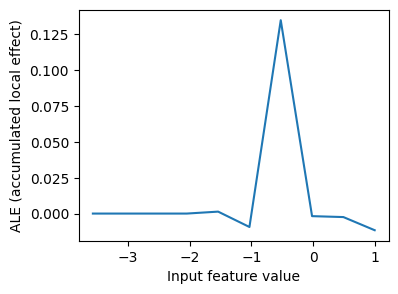

Eig03_EA


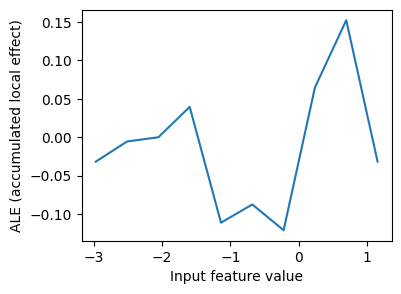

B03[C-N]


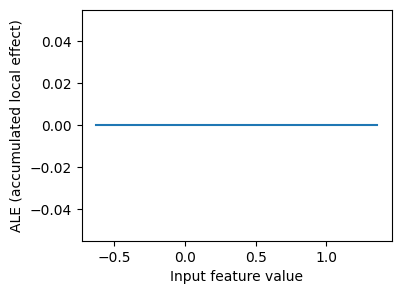

S1K


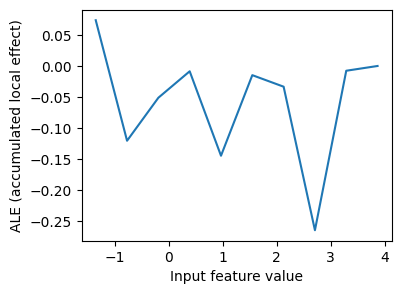

piPC05


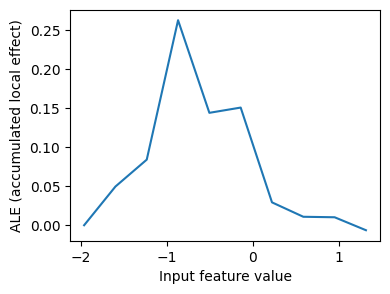

piPC07


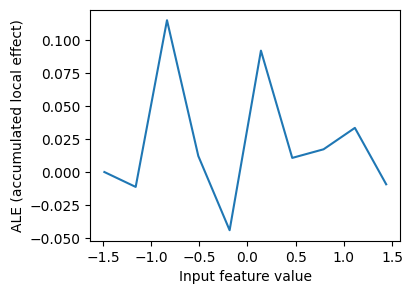

AAC


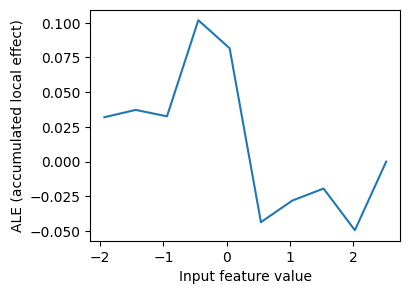

SIC4


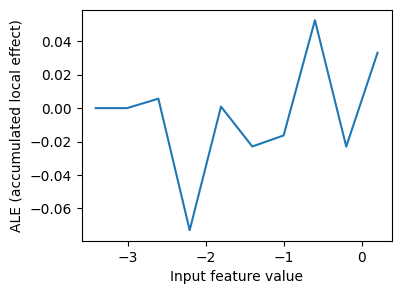

SpDiam_B(e)


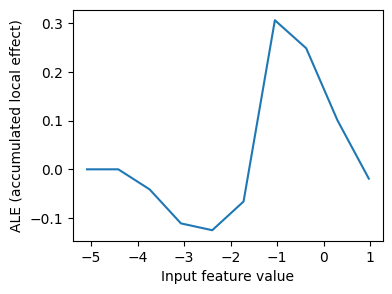

SpMax1_Bh(i)


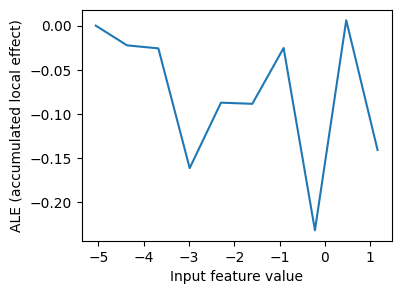

Mor31v


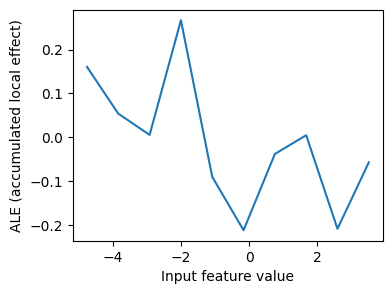

TE1


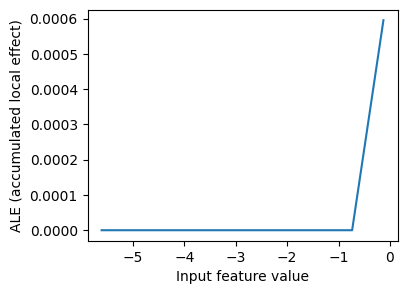

In [ ]:
for i in range(len(feat_cols)):
    print(feat_cols[i])
    get_ALE(
        X=X_train_std,
        model_fit=SVM_best_fit_std,
        feat_index=i
    )